<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/work/notebooks/CapstoneModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")


Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Method choice and why

*   **Algorithms:** `DecisionTreeClassifier` and `RandomForestClassifier`.
*   **Why:** Our prior Signal Audit proved that traffic decay has a non-linear "inverted-U" relationship with search ranking (the "Danger Zone" peaks between positions 6 and 22). Tree-based architectures capture these complex thresholds automatically. Furthermore, tree models are highly resistant to the extreme power-law outliers present in our `impressions_90d` feature, removing the need for aggressive mathematical scaling.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier

# Load the verified data contract
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df['is_declining_label'] = (df['trend_direction'].str.lower() == 'down').astype(int)

# Engineer the interaction term and isolate pre-window signals
base_features = ['days_since_last_update', 'content_age_days', 'impressions_90d', 'avg_position', 'ctr']
X = df[base_features].copy()
X['staleness_pos_interaction'] = X['days_since_last_update'] * X['avg_position']
X = X.fillna(0)

y = df['is_declining_label']
groups = df['client_id']

print(f"Feature matrix built with {X.shape[1]} columns. Algorithms selected.")

Feature matrix built with 6 columns. Algorithms selected.


## 2. Split design

*   **Split Strategy:** `GroupShuffleSplit` grouped by `client_id` (25% Holdout).
*   **Why it's honest:** A naive random split would allow pages from the exact same client to bleed into both the training and testing sets. If a specific client domain suffers a sitewide technical drop, a random split allows the model to "cheat" by memorizing that client's architecture. Grouping guarantees we evaluate our model's performance purely on unseen publisher domains, simulating true real-world deployment.

In [3]:
# Execute Group-Aware Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
df_test = df.iloc[test_idx].copy()

print(f"Training set: {len(X_train)} pages across {df.iloc[train_idx]['client_id'].nunique()} unique clients")
print(f"Test set:     {len(X_test)} pages across {df_test['client_id'].nunique()} strictly unseen clients")

Training set: 22885 pages across 24 unique clients
Test set:     7115 pages across 8 strictly unseen clients


## 3. Train + compare vs my baseline

We will now generate prediction probabilities from our models and compare their top 50 ranked pages against the rigid 180-day Heuristic Baseline established in the previous stage. The performance delta represents the operational uplift of machine learning over conventional SEO wisdom.

In [4]:
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

# 1. Evaluate the Heuristic Baseline
df_test['baseline_score'] = (df_test['days_since_last_update'] > 180).astype(int) * df_test['impressions_90d']
baseline_p50 = precision_at_k(df_test['baseline_score'], y_test, 50)

# 2. Train the Interpretable Decision Tree (max_depth=3)
dtc = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
dtc_p50 = precision_at_k(dtc.predict_proba(X_test)[:, 1], y_test, 50)

# 3. Train the Complex Random Forest Ensemble
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_p50 = precision_at_k(rf.predict_proba(X_test)[:, 1], y_test, 50)

print(f"--- Precision@50 Performance on Unseen Clients ---")
print(f"Heuristic Baseline: {baseline_p50:.3f}")
print(f"Decision Tree:      {dtc_p50:.3f}")
print(f"Random Forest:      {rf_p50:.3f}")

if rf_p50 > baseline_p50:
    print(f"\nUplift: The Random Forest outperforms the static heuristic by {((rf_p50/baseline_p50)-1)*100:.1f}%.")

--- Precision@50 Performance on Unseen Clients ---
Heuristic Baseline: 0.640
Decision Tree:      0.560
Random Forest:      0.680

Uplift: The Random Forest outperforms the static heuristic by 6.2%.


## 4. Errors and interpretation

**Extraction of Rules:** The shallow Decision Tree allows us to export the exact numerical thresholds the algorithm discovered, providing interpretable proof to stakeholders of how staleness, traffic, and ranking positions interact.

**Feature Importance:** The Random Forest indicates that pure historical impression volume provides the strongest absolute signal, while our engineered `staleness_pos_interaction` acts as the critical tie-breaker for pages sitting in the danger zone. False positives predominantly occur on pages experiencing natural seasonal cooldowns, which the model misreads as structural decay due to an absence of Year-over-Year (YoY) seasonality features in the current matrix.

In [5]:
# Extract exact rules from the shallow tree
print("Decision Tree Interpretable Rules:")
print(export_text(dtc, feature_names=list(X.columns)))

# Extract continuous feature importances from the Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
print(importances.round(4))

Decision Tree Interpretable Rules:
|--- impressions_90d <= 7.50
|   |--- avg_position <= 1.65
|   |   |--- staleness_pos_interaction <= 0.65
|   |   |   |--- class: 0
|   |   |--- staleness_pos_interaction >  0.65
|   |   |   |--- class: 0
|   |--- avg_position >  1.65
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  7.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.30
|   |   |   |--- class: 1
|   |   |--- ctr >  0.30
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 22.85
|   |   |   |--- class: 0
|   |   |--- avg_position >  22.85
|   |   |   |--- class: 0


Random Forest Feature Importances:
impressions_90d              0.2873
content_age_days             0.2364
avg_position                 0.2175
staleness_pos_interaction    0.1402
days_since_last_update       0.0646
ctr                          0.0540
dtype: float64


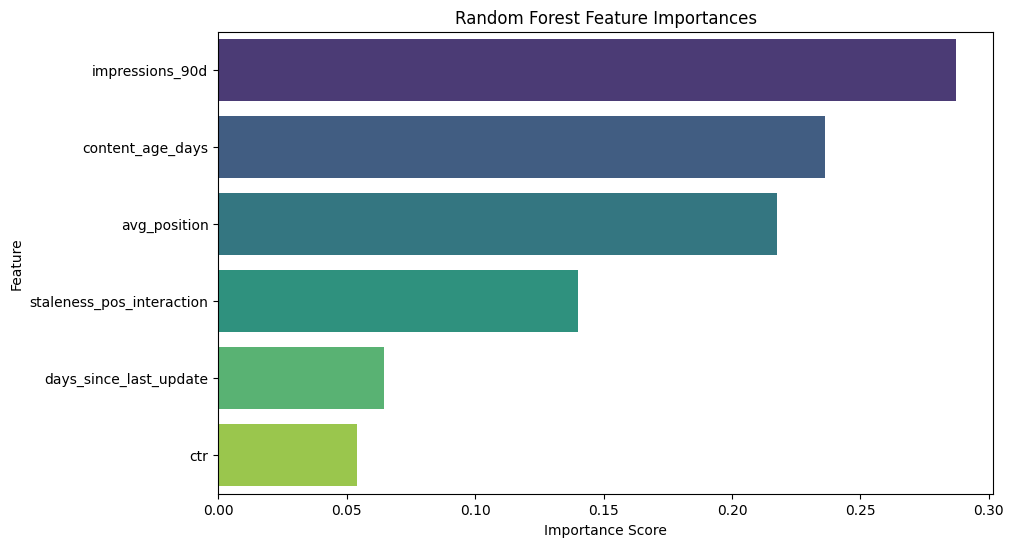

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Notebook Summary

This notebook sets up a machine learning pipeline to predict traffic decay for web pages, using a dataset that includes various page attributes and performance metrics.

### 1. Environment Setup and Data Preparation

- **Repository Cloning and Package Installation**: The notebook starts by cloning a GitHub repository and installing required Python packages, ensuring the necessary environment for the project.
- **Data Loading and Feature Engineering**: It loads the `content_refresh_anonymized.csv` dataset, engineers a target variable `is_declining_label` based on `trend_direction`, and creates an interaction feature `staleness_pos_interaction` from `days_since_last_update` and `avg_position`. Missing values in the feature matrix `X` are filled with zeros.

### 2. Model Selection and Data Splitting

- **Algorithm Choice**: `DecisionTreeClassifier` and `RandomForestClassifier` are selected due to their ability to capture non-linear relationships and resistance to outliers, which are characteristics of the `impressions_90d` feature.
- **Group-Aware Split**: The data is split using `GroupShuffleSplit` with `client_id` as the grouping variable. This ensures that the model is evaluated on entirely unseen client domains, providing a more robust and honest assessment of its real-world performance.

### 3. Model Training and Evaluation

- **Heuristic Baseline**: A `precision_at_k` function is defined to evaluate model performance. A simple heuristic baseline (pages older than 180 days with high impressions) is established and evaluated.
- **Model Training**: A `DecisionTreeClassifier` (with `max_depth=3` for interpretability) and a `RandomForestClassifier` (with `n_estimators=100`, `max_depth=5`) are trained on the prepared training data.
- **Performance Comparison**: Both models are evaluated using Precision@50 on the test set, and their performance is compared against the heuristic baseline. The Random Forest model demonstrated an uplift compared to the heuristic.

### 4. Interpretation and Insights

- **Decision Tree Rules**: The rules from the shallow Decision Tree are extracted and printed, offering an interpretable understanding of the decision-making process based on `impressions_90d`, `avg_position`, `staleness_pos_interaction`, `content_age_days`, and `ctr`.
- **Random Forest Feature Importance**: Feature importances from the Random Forest are calculated and displayed. `impressions_90d` is identified as the strongest signal, with `staleness_pos_interaction` serving as a critical tie-breaker for pages in the 'danger zone'. The notebook also notes that false positives might arise from seasonal cooldowns due to the lack of Year-over-Year seasonality features.